# Week 3: Bivariate and Multivariate Analysis

Dataset: Airbnb listings, using the cleaned CSV from the earlier assignment.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import display


## Part A : Quick Data Audit

In [2]:
# 1. Load the dataset.
df = pd.read_csv("data/processed/Airbnb_Open_Data_Cleaned.csv", low_memory=False)

df_shape = df.shape

# 2. Print:
# shape (#rows, #columns)
print(f"Dataset shape - row: {df_shape[0]} col: {df_shape[1]}")

#df_describe= df.describe()

#df_sats = df_describe[["name",""]]

# column names + data types
#col_names = df.columns.values.tolist
col_dtypes = df.dtypes

print(f"columns names and dtypes:")
print(col_dtypes)

# missing values count per column

num_missing_values = df.isna().sum()

print(f"\nNumber of missing values:\n{num_missing_values}")

# basic descriptive stats for numeric columns (describe())

print("\nbasic descriptive stats for numeric columns:\n")
print(df.describe())

Dataset shape - row: 102599 col: 26
columns names and dtypes:
id                                  int64
name                                  str
host_id                             int64
host_identity_verified                str
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country_code                          str
instant_bookable                   object
cancellation_policy                   str
room_type                             str
construction_year                 float64
price                             float64
service_fee                       float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
review_rate_number                float64
calculated_hos

The price looks like a possible target, if the aim is to predict the cost of a listing. Columns like room_type, neighbourhood, minimum_nights and construction_year could be inputs, and number_of_reviews could be another target for a different question. The id and host_id columns identify listings and hosts, so their numbers should not be treated like measurements.

### Basic validity checks

Minimum nights should be at least 1, and availability_365 should be between 0 and 365 days. I replaced values outside these limits with missing values, negative longitude values are okay like this, because they can be negative.

In [3]:
# marking invalid values as missing in the working dataframe
invalid_nights =  df["minimum_nights"] < 1
invalid_availability = (df["availability_365"] < 0) | (df["availability_365"] > 365)

print("Invalid minimum_nights:", invalid_nights.sum())
print("Invalid availability_365:", invalid_availability.sum())

df.loc[invalid_nights, "minimum_nights"] = np.nan
df.loc[invalid_availability, "availability_365"] = np.nan

Invalid minimum_nights: 13
Invalid availability_365: 3214


## Part B : Bivariate Analysis
1. Pick two pairs of variables for bivariate analysis:
2. Pair 1: two numeric variables where you expect a relationship.
3. Pair 2: two numeric variables where you are not sure (or suspect weak/nonlinear/outlier-driven effects).

I chose price and service_fee for the first pair, because I expect higher prices to have higher fees. For the second pair I used price and minimum_nights because   higher prices also mean longer minimum stays.

### B1. Visualize relationships

The scatter plots use rows where both values are present. The boxplot shows price for each room_type.

In [4]:
#pair 1
pair_1 = df[["price","service_fee"]].dropna()
#pair 2
pair_2 = df[["price","minimum_nights"]].dropna()

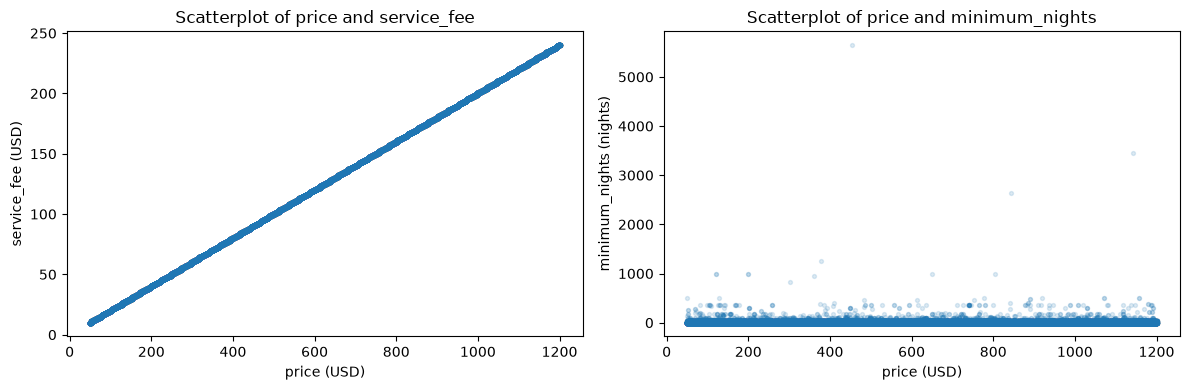

In [5]:
#scatter plot 

fig, axes = plt.subplots(1,2, figsize = (12,4))

pair_1_col_1 = pair_1.iloc[:,0]
pair_1_col_2 = pair_1.iloc[:,1]

pair_2_col_1 = pair_2.iloc[:,0]
pair_2_col_2 = pair_2.iloc[:,1]


axes[0].scatter(pair_1_col_1, pair_1_col_2,  s=8,alpha=0.15)
axes[0].set_title(f"Scatterplot of {pair_1_col_1.name} and {pair_1_col_2.name}")
axes[0].set_xlabel(pair_1_col_1.name + " (USD)")
axes[0].set_ylabel(pair_1_col_2.name + " (USD)")


axes[1].scatter(pair_2_col_1, pair_2_col_2, s=8, alpha=0.15)
axes[1].set_title(f"Scatterplot of {pair_2_col_1.name} and {pair_2_col_2.name}")
axes[1].set_xlabel(pair_2_col_1.name + " (USD)")
axes[1].set_ylabel(pair_2_col_2.name + " (nights)")

plt.tight_layout()
plt.show()

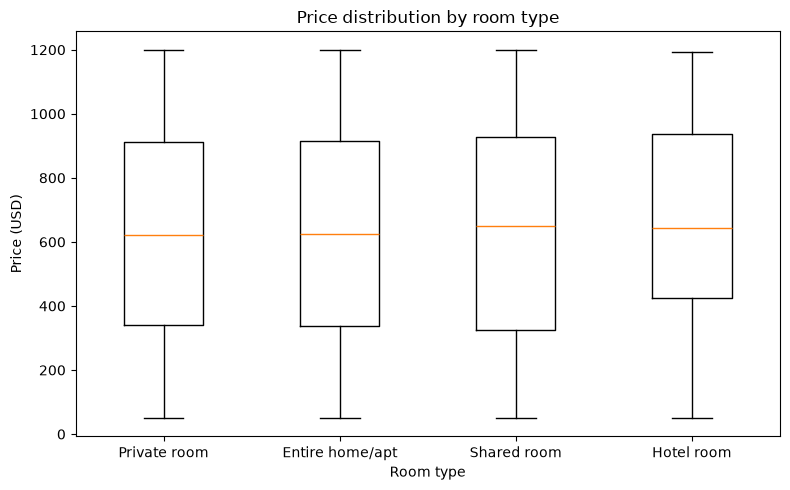

,count,median
room_type,,
Entire home/apt,53568,624.0
Hotel room,116,644.5
Private room,46450,623.0
Shared room,2218,651.0


In [6]:
# Compare price across room types.
room_types = df["room_type"].dropna().unique()
room_prices = []

for room_type in room_types:
    prices = df.loc[df["room_type"] == room_type, "price"].dropna()
    room_prices.append(prices)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(room_prices, tick_labels=room_types)
ax.set_title("Price distribution by room type")
ax.set_xlabel("Room type")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

room_summary = df.groupby("room_type")["price"].agg(["count", "median"])
display(room_summary)

The service_fee has a strong positive linear relation with price. Price and minimum_nights do not show a clear upward or downward pattern  and a few very large minimum_nights values stretch the plot. The room type boxplots overlap a lot, with median prices between about  623usd and 651usd

### B2. Covariance, Pearson and Spearman

I used the same rows for the three calculations in each pair. The covariance calculation uses n-1 as this is sample covariance.

In [7]:
pair_statistics = []

for pair_name, pair in [("Pair 1: price / service_fee", pair_1),
                        ("Pair 2: price / minimum_nights", pair_2)]:
    covariance = pair.cov().iloc[0,1]
    pearson_r = pair.corr(method="pearson").iloc[0,1]
    spearman_r = pair.corr(method="spearman").iloc[0,1]

    pair_statistics.append({
        "Pair": pair_name,
        "Rows": len(pair),
        "Covariance": covariance,
        "Pearson r": pearson_r,
        "Spearman": spearman_r,
    })

statistics_table = pd.DataFrame(pair_statistics).set_index("Pair")
display(statistics_table.round(6))

pair_1_r = pair_1.corr(method="pearson").iloc[0,1]

pair_1_r_squared = pair_1_r ** 2
print(f"Pair 1 r squared: {pair_1_r_squared:.6f} ({pair_1_r_squared * 100:.4f}%)")

,Rows,Covariance,Pearson r,Spearman
Pair,,,,
Pair 1: price / service_fee,102113,21999.347802,0.999991,0.999991
Pair 2: price / minimum_nights,101930,-29.206289,-0.002908,-0.004387


Pair 1 r squared: 0.999982 (99.9982%)


Price and service_fee have almost perfect positive correlation with both Pearson and Spearman close to 1. For price and minimum_nights, both values are close to zero so there is no clear linear relation. Covariance  depends on the units so the correlation values are easier to compare between the pairs.

For Pair 1, r squared is about 0.99998 meaning that a straight-line model with an intercept explains about 99.998% of the variation in service_fee using price.

### B3. Outlier / nonlinearity check

I used the IQR rule on minimum_nights  with limits of Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. The values outside these limits are left out for the second correlation calculation.

In [8]:
q1 = pair_2["minimum_nights"].quantile(0.25)
q3 = pair_2["minimum_nights"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outlier_mask = ((pair_2["minimum_nights"] < lower_limit) |
                (pair_2["minimum_nights"] > upper_limit))
pair_2_without_outliers = pair_2.loc[~outlier_mask]

r_with_outliers = pair_2.corr(method="pearson").iloc[0, 1]
r_without_outliers = pair_2_without_outliers.corr(method="pearson").iloc[0, 1]

print(f"IQR limits: {lower_limit:.1f} to {upper_limit:.1f} nights")
print(f"Potential outliers: {outlier_mask.sum()} ({outlier_mask.mean() * 100:.2f}%)")

outlier_comparison = pd.DataFrame({
    "Rows": [len(pair_2), len(pair_2_without_outliers)],
    "Pearson r": [r_with_outliers, r_without_outliers],
}, index=["with potential outliers", "without potential outliers"])
display(outlier_comparison.round(6))

IQR limits: -2.5 to 9.5 nights
Potential outliers: 18319 (17.97%)


,Rows,Pearson r
With potential outliers,101930,-0.002908
Without potential outliers,83611,-0.005249


The Pearson correlation changes from about -0.0029 to -0.0052 after removing the outliers, so the difference is small and both values are still close to zero. This means the very long stays do not hide a strong linear relation, although a nonlinear pattern could still exist. The IQR rule identifies 18,319 listings with minimum_nights of 10 or more as potential outliers, but this does not mean all of them are errors.

## Part C : Multivariate Analysis

### C1. Correlation matrix

I used nine numeric columns, without id and host_id. Each correlation uses the rows where both columns have values.

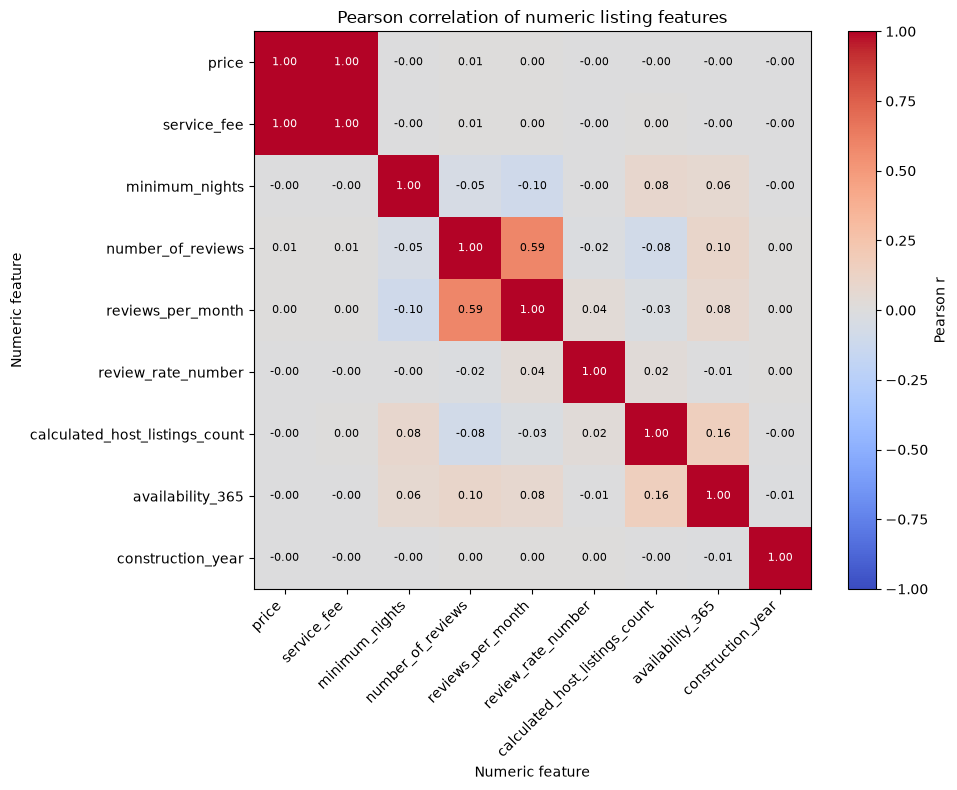

Top 3 positive correlations:


,Variable 1,Variable 2,Pearson r
0,price,service_fee,0.999991
1,number_of_reviews,reviews_per_month,0.590939
2,calculated_host_listings_count,availability_365,0.159194


Top 3 negative correlations:


,Variable 1,Variable 2,Pearson r
0,minimum_nights,reviews_per_month,-0.096141
1,number_of_reviews,calculated_host_listings_count,-0.080907
2,minimum_nights,number_of_reviews,-0.049997


In [27]:
numeric_columns = [
    "price", "service_fee",
    "minimum_nights",
    "number_of_reviews", 
    "reviews_per_month", 
    "review_rate_number", 
    "calculated_host_listings_count",
    "availability_365", 
    "construction_year",
    ]

correlation_matrix = df[numeric_columns].corr(method="pearson")


fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(numeric_columns)), labels=numeric_columns,
              rotation=45, ha="right")
ax.set_yticks(np.arange(len(numeric_columns)), labels=numeric_columns)
ax.set_title("Pearson correlation of numeric listing features")
ax.set_xlabel("Numeric feature")
ax.set_ylabel("Numeric feature")


for row in range(len(numeric_columns)):
    for col in range(len(numeric_columns)):
        value = correlation_matrix.iloc[row, col]
        text_color = "white" if abs(value) > 0.6 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                color=text_color, fontsize=8)

fig.colorbar(heatmap, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()


# using each pair once without self correlations or mirrored duplicates
correlation_pairs = []
for i in range(len(numeric_columns)):
    for j in range(i + 1, len(numeric_columns)):
        correlation_pairs.append({
            "Variable 1": numeric_columns[i],
            "Variable 2": numeric_columns[j],
            "Pearson r": correlation_matrix.iloc[i, j],
        })

correlation_pairs = pd.DataFrame(correlation_pairs)
top_positive = correlation_pairs[correlation_pairs["Pearson r"] > 0].nlargest(3, "Pearson r")
top_negative = correlation_pairs[correlation_pairs["Pearson r"] < 0].nsmallest(3, "Pearson r")


print("Top 3 positive correlations:")


display(top_positive.reset_index(drop=True).round(6))
print("Top 3 negative correlations:")
display(top_negative.reset_index(drop=True).round(6))

Price and service_fee have the strongest positive correlation, about 0.99999, so they give almost the same information and could cause multicollinearity if both are used as inputs. Number_of_reviews and reviews_per_month are also related, with a correlation of about 0.591, but this relation is less strong. The three strongest negative correlations all have absolute values below 0.1, mening they are weak negative relations in these columns.

### C2. Scaling / normalization impact

I used price, number_of_reviews and reviews_per_month, because they have different units and scales. The before and after tables use the same rows, and the z-score calculation uses the sample standard deviation.

Before                         After                    
                      mean      std    min     max  mean  std    min     max
price              626.060  331.664  50.00  1200.0   0.0  1.0 -1.737   1.730
number_of_reviews   32.467   52.282   1.00  1024.0  -0.0  1.0 -0.602  18.965
reviews_per_month    1.375    1.748   0.01    90.0  -0.0  1.0 -0.781  50.701

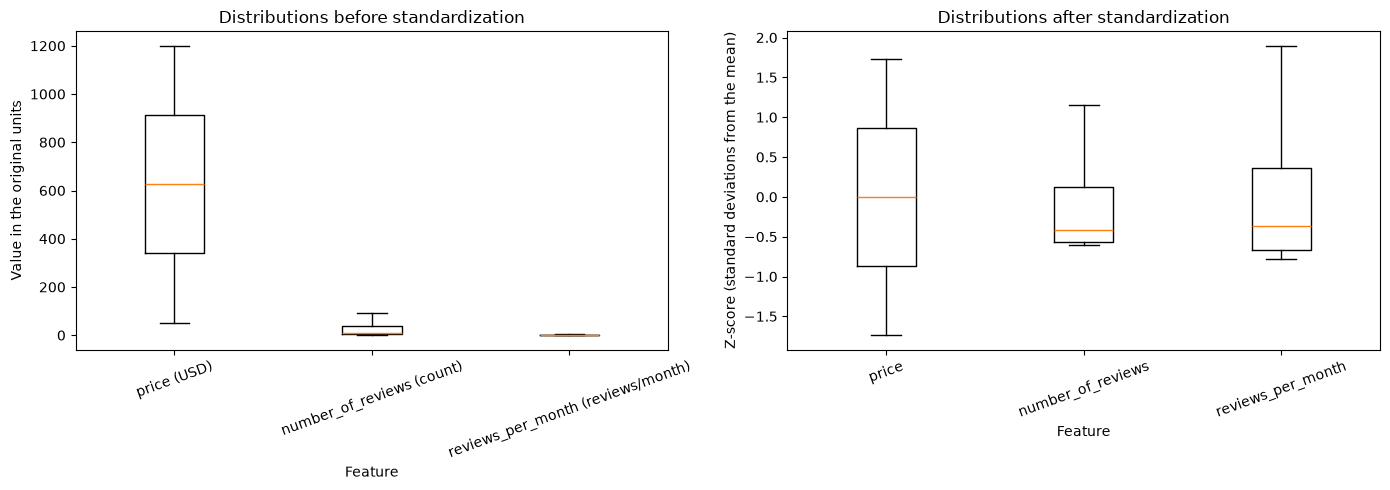

In [10]:
scaling_columns = ["price", "number_of_reviews", "reviews_per_month"]
before_scaling = df[scaling_columns].dropna()
after_scaling = (before_scaling - before_scaling.mean()) / before_scaling.std()


before_stats = before_scaling.agg(["mean", "std", "min", "max"]).T
after_stats = after_scaling.agg(["mean", "std", "min", "max"]).T
scaling_summary = pd.concat({"Before": before_stats, "After": after_stats}, axis=1)
display(scaling_summary.round(3))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([before_scaling[col] for col in scaling_columns],
                tick_labels=["price (USD)", "number_of_reviews (count)",
                             "reviews_per_month (reviews/month)"], showfliers=False)
axes[0].set_title("Distributions before standardization")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Value in the original units")

axes[1].boxplot([after_scaling[col] for col in scaling_columns],
                tick_labels=scaling_columns, showfliers=False)
axes[1].set_title("Distributions after standardization")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Z-score (standard deviations from the mean)")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=20)

plt.tight_layout()
plt.show()

Scaling is important for methods like K-means , because the larger numbers in price could have much more effect on distances than reviews_per_month. 
After standardization, the mean is close to 0 and the standard deviation is 1 for each column, but the outliers are still there.

### C3. Missing values

I used minimum_nights, which has missing values, including the invalid values replaced in Part A . I kept rows with a known price, then compared dropping missing minimum_nights values with filling them using the median.


In [11]:
missing_subset = df[["price", "minimum_nights"]].dropna(subset=["price"])
missing_count = missing_subset["minimum_nights"].isna().sum()

print(f"Missing minimum_nights: {missing_count} out of {len(missing_subset)} rows")
print(f"Missing percentage: {missing_count / len(missing_subset) * 100:.2f}%")

# approach 1: drop the rows with missing minimum nights
dropped_subset = missing_subset.dropna(subset=["minimum_nights"])

# approach 2 : replace missing minimum nights with the median
# the median is useful here because minimum nights is strongly skewed

imputed_subset = missing_subset.copy()
median_nights = imputed_subset["minimum_nights"].median()
imputed_subset["minimum_nights"] = imputed_subset["minimum_nights"].fillna(median_nights)
print(f"Median used for imputation: {median_nights:.0f} nights")


missing_comparison = pd.DataFrame({
    "Rows": [len(dropped_subset), len(imputed_subset)],
    "Pearson r": [dropped_subset.corr().iloc[0, 1],
                  imputed_subset.corr().iloc[0, 1]],
    "Covariance": [dropped_subset.cov().iloc[0, 1],
                   imputed_subset.cov().iloc[0, 1]],
}, index=["Drop missing rows", "Median imputation"])
display(missing_comparison.round(6))

Missing minimum_nights: 422 out of 102352 rows
Missing percentage: 0.41%
Median used for imputation: 3 nights


,Rows,Pearson r,Covariance
Drop missing rows,101930,-0.002908,-29.206289
Median imputation,102352,-0.002875,-28.819652


The two methods give almost the same Pearson correlation, about -0.0029 in both cases, so the result seems stable in this comparison. I would use dropping here, because only about 0.41% of the rows are affected and filling them with the median would add repeated values that were not actually observed.